# CIFAR-10 - Fully Connected Network (FCN)

In [9]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from keras.layers import Dropout

import numpy as np
import matplotlib.pyplot as plt

Input is flattened (32×32×3 → 3072) since FCN ignores spatial structure.  Two hidden fully connected layers (512, 256, 128 neurons) learn features. ReLU adds non-linearity, softmax outputs class probabilities.

In [21]:
# Creating the FCN model: 
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_fcn")

CIFAR-10 is loaded and normalized to [0,1] for stable training. Labels are flattened to match sparse loss format. Adam optimizer and cross-entropy are used for efficient classification. Model is trained for 20 epochs with validation split to monitor generalization.

In [22]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() # load the cifar-10 dataset

y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

model.summary()

# Training the model
history = model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2)

Model: "cifar10_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1774796615.071342    1740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_392258__.14
I0000 00:00:1774796615.572251    1740 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3118 - loss: 1.8933 - val_accuracy: 0.3642 - val_loss: 1.7574
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3853 - loss: 1.7043 - val_accuracy: 0.3796 - val_loss: 1.7204
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4164 - loss: 1.6217 - val_accuracy: 0.4134 - val_loss: 1.6185
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4401 - loss: 1.5655 - val_accuracy: 0.4260 - val_loss: 1.5980
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4536 - loss: 1.5217 - val_accuracy: 0.4351 - val_loss: 1.5776
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4644 - loss: 1.4892 - val_accuracy: 0.4412 - val_loss: 1.5931
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4778 - loss: 1.4563 - val_accuracy: 0.4478 - val_loss: 1.5569
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4895 - loss: 1.4257 - val_accurac

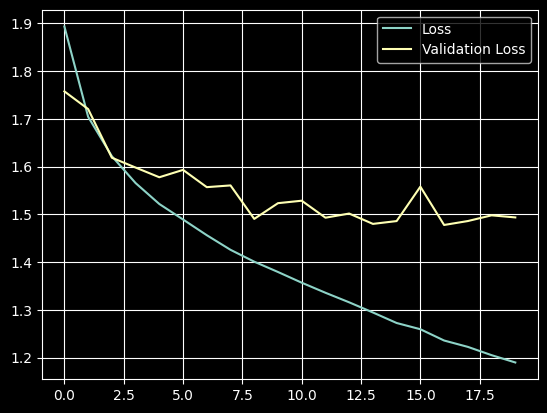

In [23]:
# Plot training and validation loss per epoch
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

Training accuracy improves steadily (~32% → ~57%), showing learning progress. Validation accuracy peaks around ~48–49%, lower than training → slight overfitting. Loss decreases consistently, but validation loss plateaus after ~10 epochs. Model converges, but performance is limited due to lack of spatial feature learning.

In [24]:
# Evaluate final model on unseen test data
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 3ms/step - accuracy: 0.4953 - loss: 1.4746
Test loss: 1.4745728969573975
Test accuracy: 0.4952999949455261


Test accuracy ≈ 49.5%, close to validation accuracy → good generalization. Performance matches expected FCN range (~50%). Limitations due to ignoring spatial structure in images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


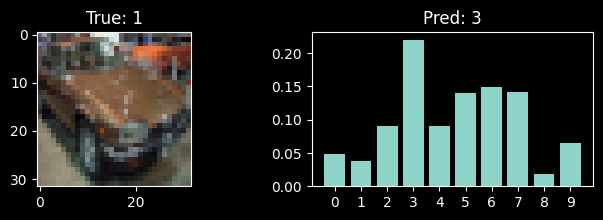

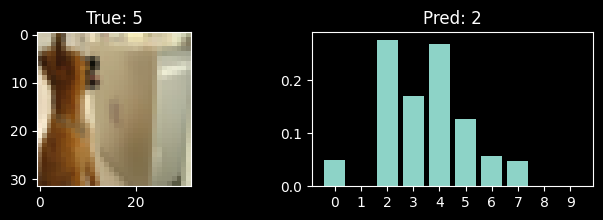

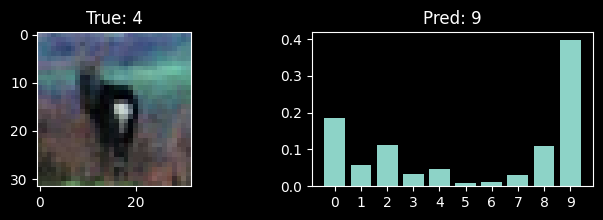

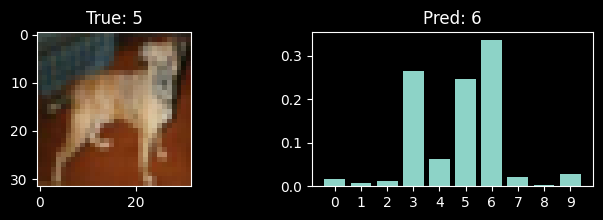

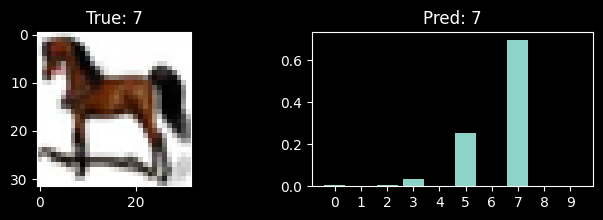

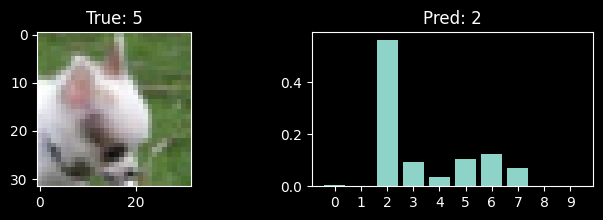

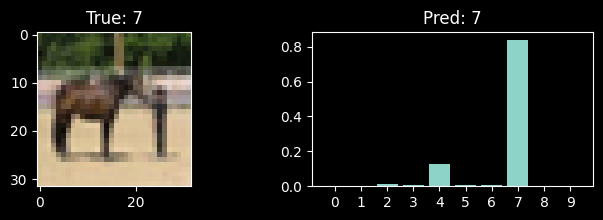

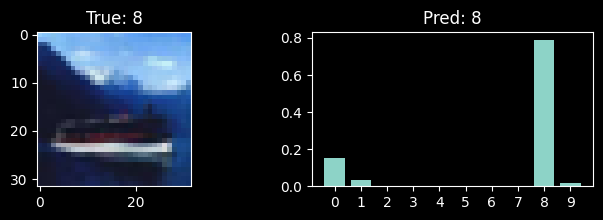

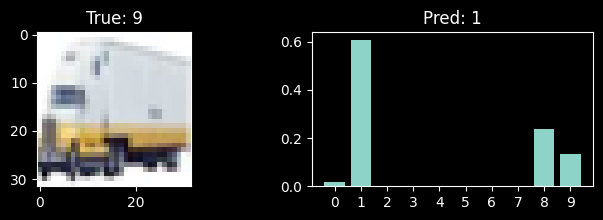

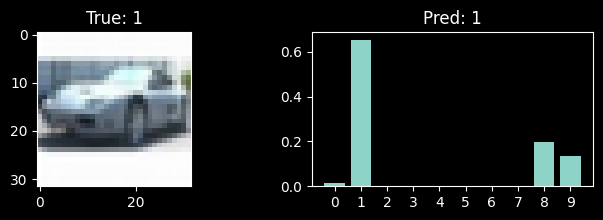

In [25]:
y_pred = model.predict(x_test)
start = 2000

# visualization
for k in range(10):
    plt.figure(figsize=(8, 2))

    plt.subplot(1,2,1)
    plt.imshow(x_test[start+k])
    plt.title(f"True: {y_test[start+k]}")

    plt.subplot(1,2,2)
    plt.bar(range(10), y_pred[start+k].flatten())
    plt.title(f"Pred: {np.argmax(y_pred[start+k])}")

    plt.xticks(range(10))
    plt.show()

For FCN regularization, we use Dropout, which randomly drops 20% of the neurons. We keep the same number of hidden layers, batch size, and number of epochs as the baseline model.

In [26]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_fcn_dropout")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2)

Epoch 1/20


I0000 00:00:1774796804.836307    1743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_523486__.17
I0000 00:00:1774796804.966777    1743 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2347 - loss: 2.0365 - val_accuracy: 0.3100 - val_loss: 1.8705
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2921 - loss: 1.9094 - val_accuracy: 0.3274 - val_loss: 1.8405
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3081 - loss: 1.8778 - val_accuracy: 0.3508 - val_loss: 1.8022
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3202 - loss: 1.8486 - val_accuracy: 0.3438 - val_loss: 1.7944
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3311 - loss: 1.8247 - val_accuracy: 0.3671 - val_loss: 1.7581
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3401 - loss: 1.8068 - val_accuracy: 0.3691 - val_loss: 1.7426
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3450 - loss: 1.7920 - val_accuracy: 0.3910 - val_loss: 1.7118
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3493 - loss: 1.7826 - val_accurac

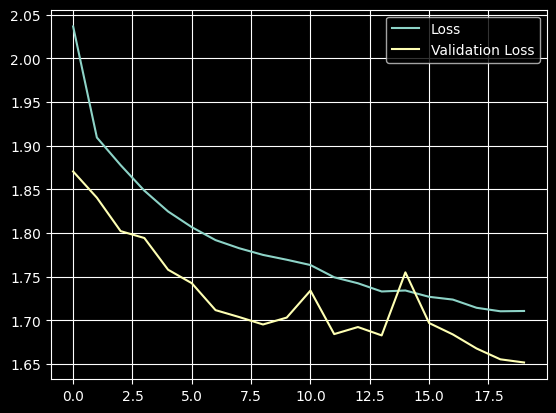

In [27]:
# Plot training and validation loss per epoch
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [28]:
# Evaluate final model on unseen test data
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 3ms/step - accuracy: 0.4178 - loss: 1.6362
Test loss: 1.6362248659133911
Test accuracy: 0.41780000925064087


Dropout slows learning, so training accuracy is lower than the baseline FCN (~57%), but validation and test accuracy improve slightly over early epochs, showing some generalization; however, since FCN lacks spatial feature learning and has limited capacity for CIFAR-10, overall accuracy remains constrained despite reduced overfitting.